# Ejercicio 1: 
Manejo de histograma
1. Cargue y visualice la im ́agenes patron2.tif y patron.tif (a esta  ́ultima util ́ıcela
a escala de grises).
Reflexione acerca de que histograma espera obtener para cada una.
Obtenga los histogramas y graf ́ıquelos.
histr = cv2.calcHist(images, channels, mask, histSize, ranges[,
hist[, accumulate]])
pyplot.plot(histr)
Identifique la informaci ́on suministrada y anal ́ıcela en relaci ́on a su ex-
pectativa.
2. Los archivos histo1.tif, histo2.tif, histo3.tif, histo4.tif e histo5.tif
contienen histogramas de im ́agenes con diferentes caracter ́ısticas. Se pide
Analizando solamente los archivos de histograma y realice una descrip-
ci ́on de la imagen a la que corresponden (¿es clara u oscura?, ¿tiene buen
contraste?, ¿el histograma me explica algo respecto de la ubicaci ́on de
los grises?, etc.).
Anote la correspondencia histograma-imagen con los archivos imagenA.tif
a imagenE.tif, bas ́andose en su an ́alisis previo.
Cargue las im ́agenes originales y muestre los histogramas. Comparelos
con sus respuestas del punto anterior.
Obtenga y analice la utilidad de las siguientes propiedades estad ́ısticas
de los histogramas: media, varianza, asimetr ́ıa, energ ́ıa y entrop ́ıa.
3. Cargue una imagen y realice la ecualizaci ́on de su histograma.
img equ = cv2.equalizeHist(img)
Muestre en una misma ventana la imagen original, la versi ́on ecualizada
y sus respectivos histogramas.
Estudie la informaci ́on suministrada por los histogramas. ¿Qu ́e diferen-
cias nota respecto a las definiciones te ́oricas?
Repita el an ́alisis para distintas im ́agenes

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# parte 1

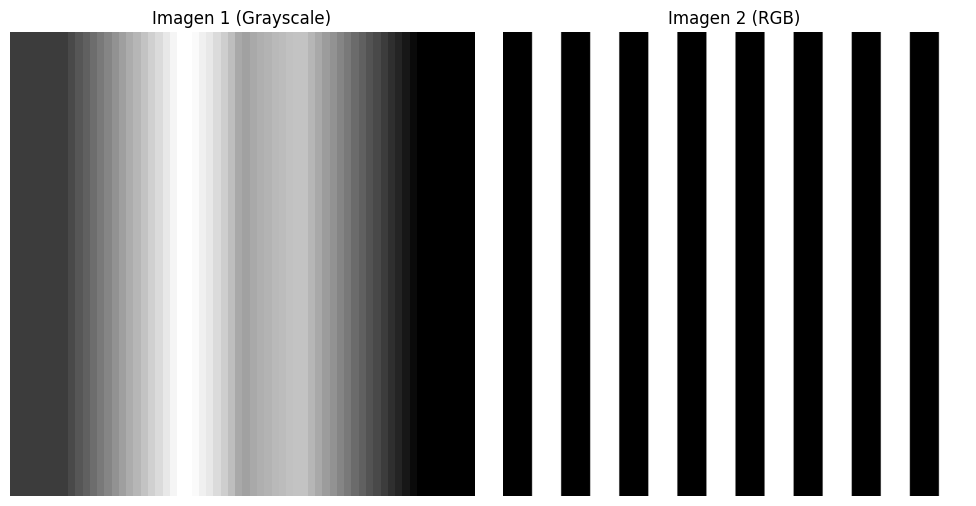

In [5]:
img_1 = cv2.imread("../Imagenes_cursado/patron.tif", cv2.IMREAD_GRAYSCALE)
img_2 = cv2.imread("../Imagenes_cursado/patron2.tif") #a color?



plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_1, cmap='gray')
plt.title('Imagen 1 (Grayscale)')
plt.axis('off')

img_2_rgb = cv2.cvtColor(img_2, cv2.COLOR_BGR2RGB)
plt.subplot(1, 2, 2)
plt.imshow(img_2_rgb)
plt.title('Imagen 2 (RGB)')
plt.axis('off')

plt.tight_layout()
plt.show()



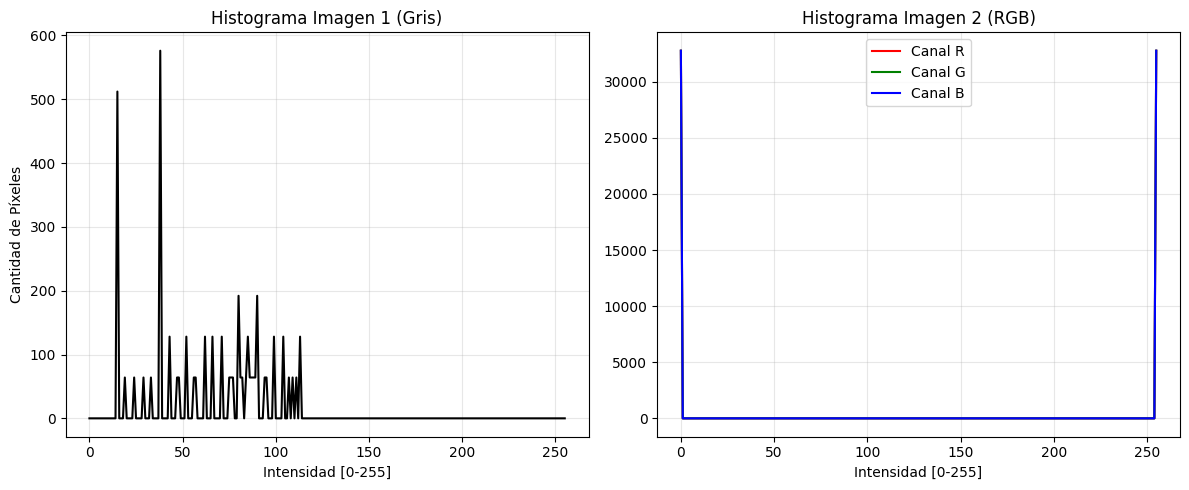

In [6]:
hist_1 = cv2.calcHist([img_1], [0], None, [256], [0, 256])

colores = ('r', 'g', 'b')
histogramas_img2 = []
for i, col in enumerate(colores):
    hist = cv2.calcHist([img_2_rgb], [i], None, [256], [0, 256])
    histogramas_img2.append(hist)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(hist_1, color='black')
plt.title('Histograma Imagen 1 (Gris)')
plt.xlabel('Intensidad [0-255]')
plt.ylabel('Cantidad de Píxeles')
plt.grid(True, alpha=0.3)


plt.subplot(1, 2, 2)
for i, col in enumerate(colores):
    plt.plot(histogramas_img2[i], color=col, label=f'Canal {col.upper()}')
plt.title('Histograma Imagen 2 (RGB)')
plt.xlabel('Intensidad [0-255]')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# parte 2

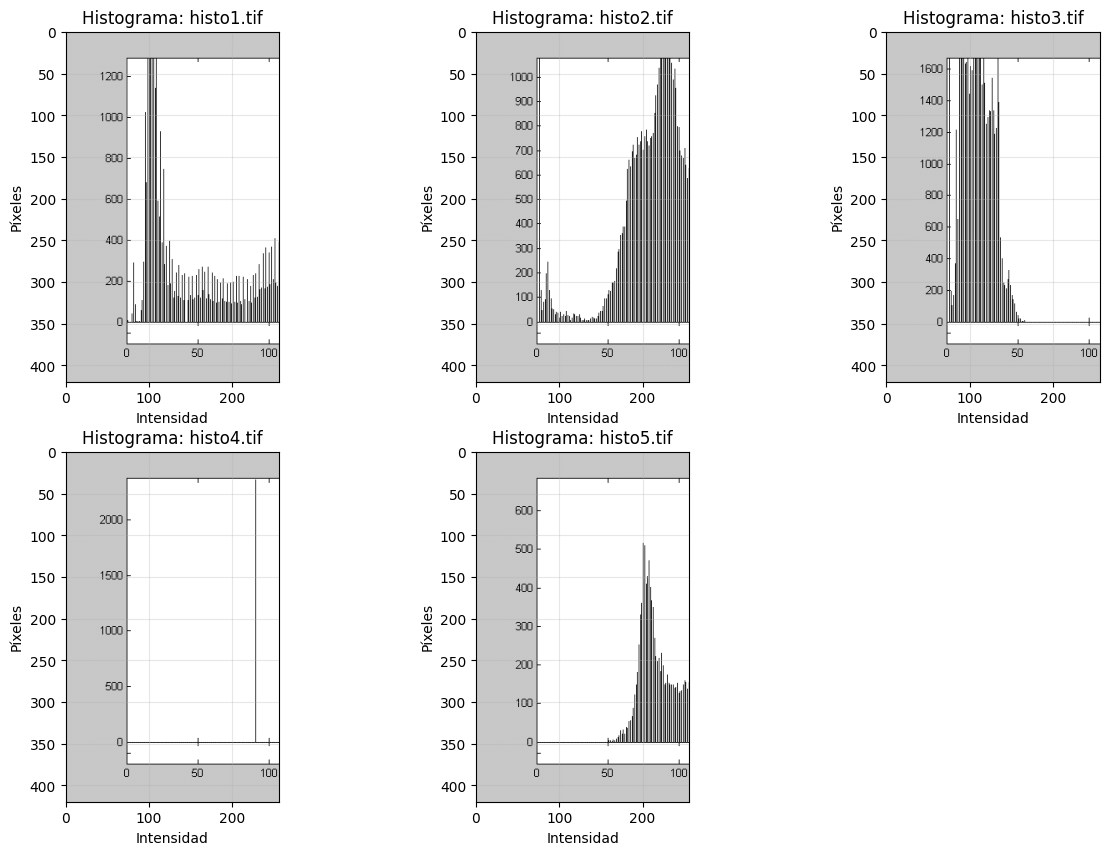

In [11]:
rutas = [
    "../Imagenes_cursado/histo1.tif",
    "../Imagenes_cursado/histo2.tif",
    "../Imagenes_cursado/histo3.tif",
    "../Imagenes_cursado/histo4.tif",
    "../Imagenes_cursado/histo5.tif"
]

plt.figure(figsize=(15, 10))

for i, ruta in enumerate(rutas):
    hist = cv2.imread(ruta, cv2.IMREAD_GRAYSCALE)
    plt.subplot(2, 3, i + 1)
    plt.imshow(hist, cmap= "gray")
    plt.title(f'Histograma: {ruta.split("/")[-1]}')
    plt.xlabel('Intensidad')
    plt.ylabel('Píxeles')
    plt.xlim([0, 256])
    plt.grid(True, alpha=0.3)

1) imagen muy oscura. Poco ecualizada.
2) imagen muy clara
3) imagen muy oscura, con pocos blancos
4) imagen o binaria (no se ve por solapamiento en cero) o constante en intensidad 90
5) imagen clara.

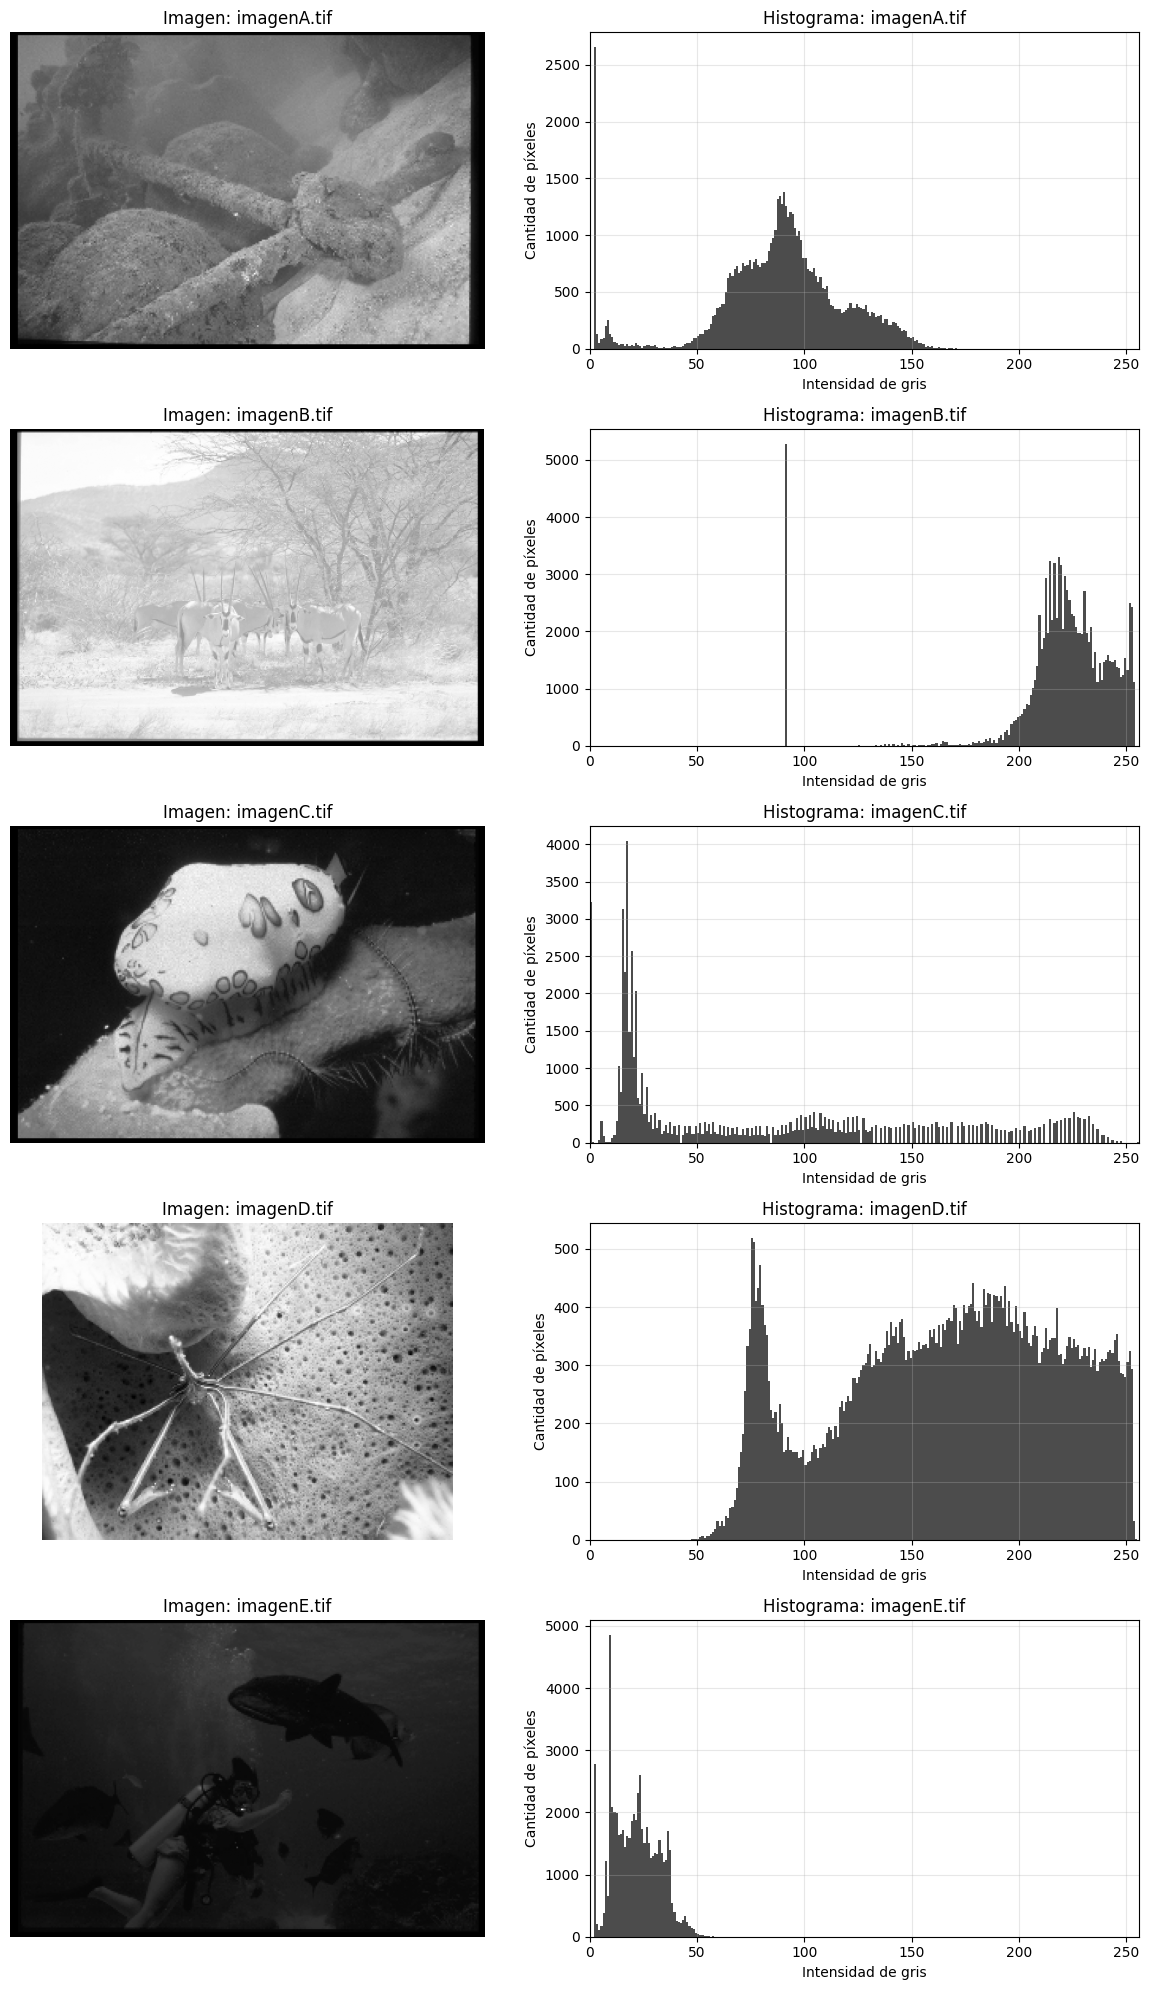

In [13]:
rutas = [
    "../Imagenes_cursado/imagenA.tif",
    "../Imagenes_cursado/imagenB.tif",
    "../Imagenes_cursado/imagenC.tif",
    "../Imagenes_cursado/imagenD.tif",
    "../Imagenes_cursado/imagenE.tif"
]

plt.figure(figsize=(12, 4 * len(rutas)))

for i, ruta in enumerate(rutas):
    img = cv2.imread(ruta, cv2.IMREAD_GRAYSCALE)

    plt.subplot(len(rutas), 2, 2 * i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(f'Imagen: {ruta.split("/")[-1]}')
    plt.axis('off')  

    plt.subplot(len(rutas), 2, 2 * i + 2)
    plt.hist(img.ravel(), bins=256, range=[0, 256], color='black', alpha=0.7)
    plt.title(f'Histograma: {ruta.split("/")[-1]}')
    plt.xlabel('Intensidad de gris')
    plt.ylabel('Cantidad de píxeles')
    plt.xlim([0, 256])
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# parte 3


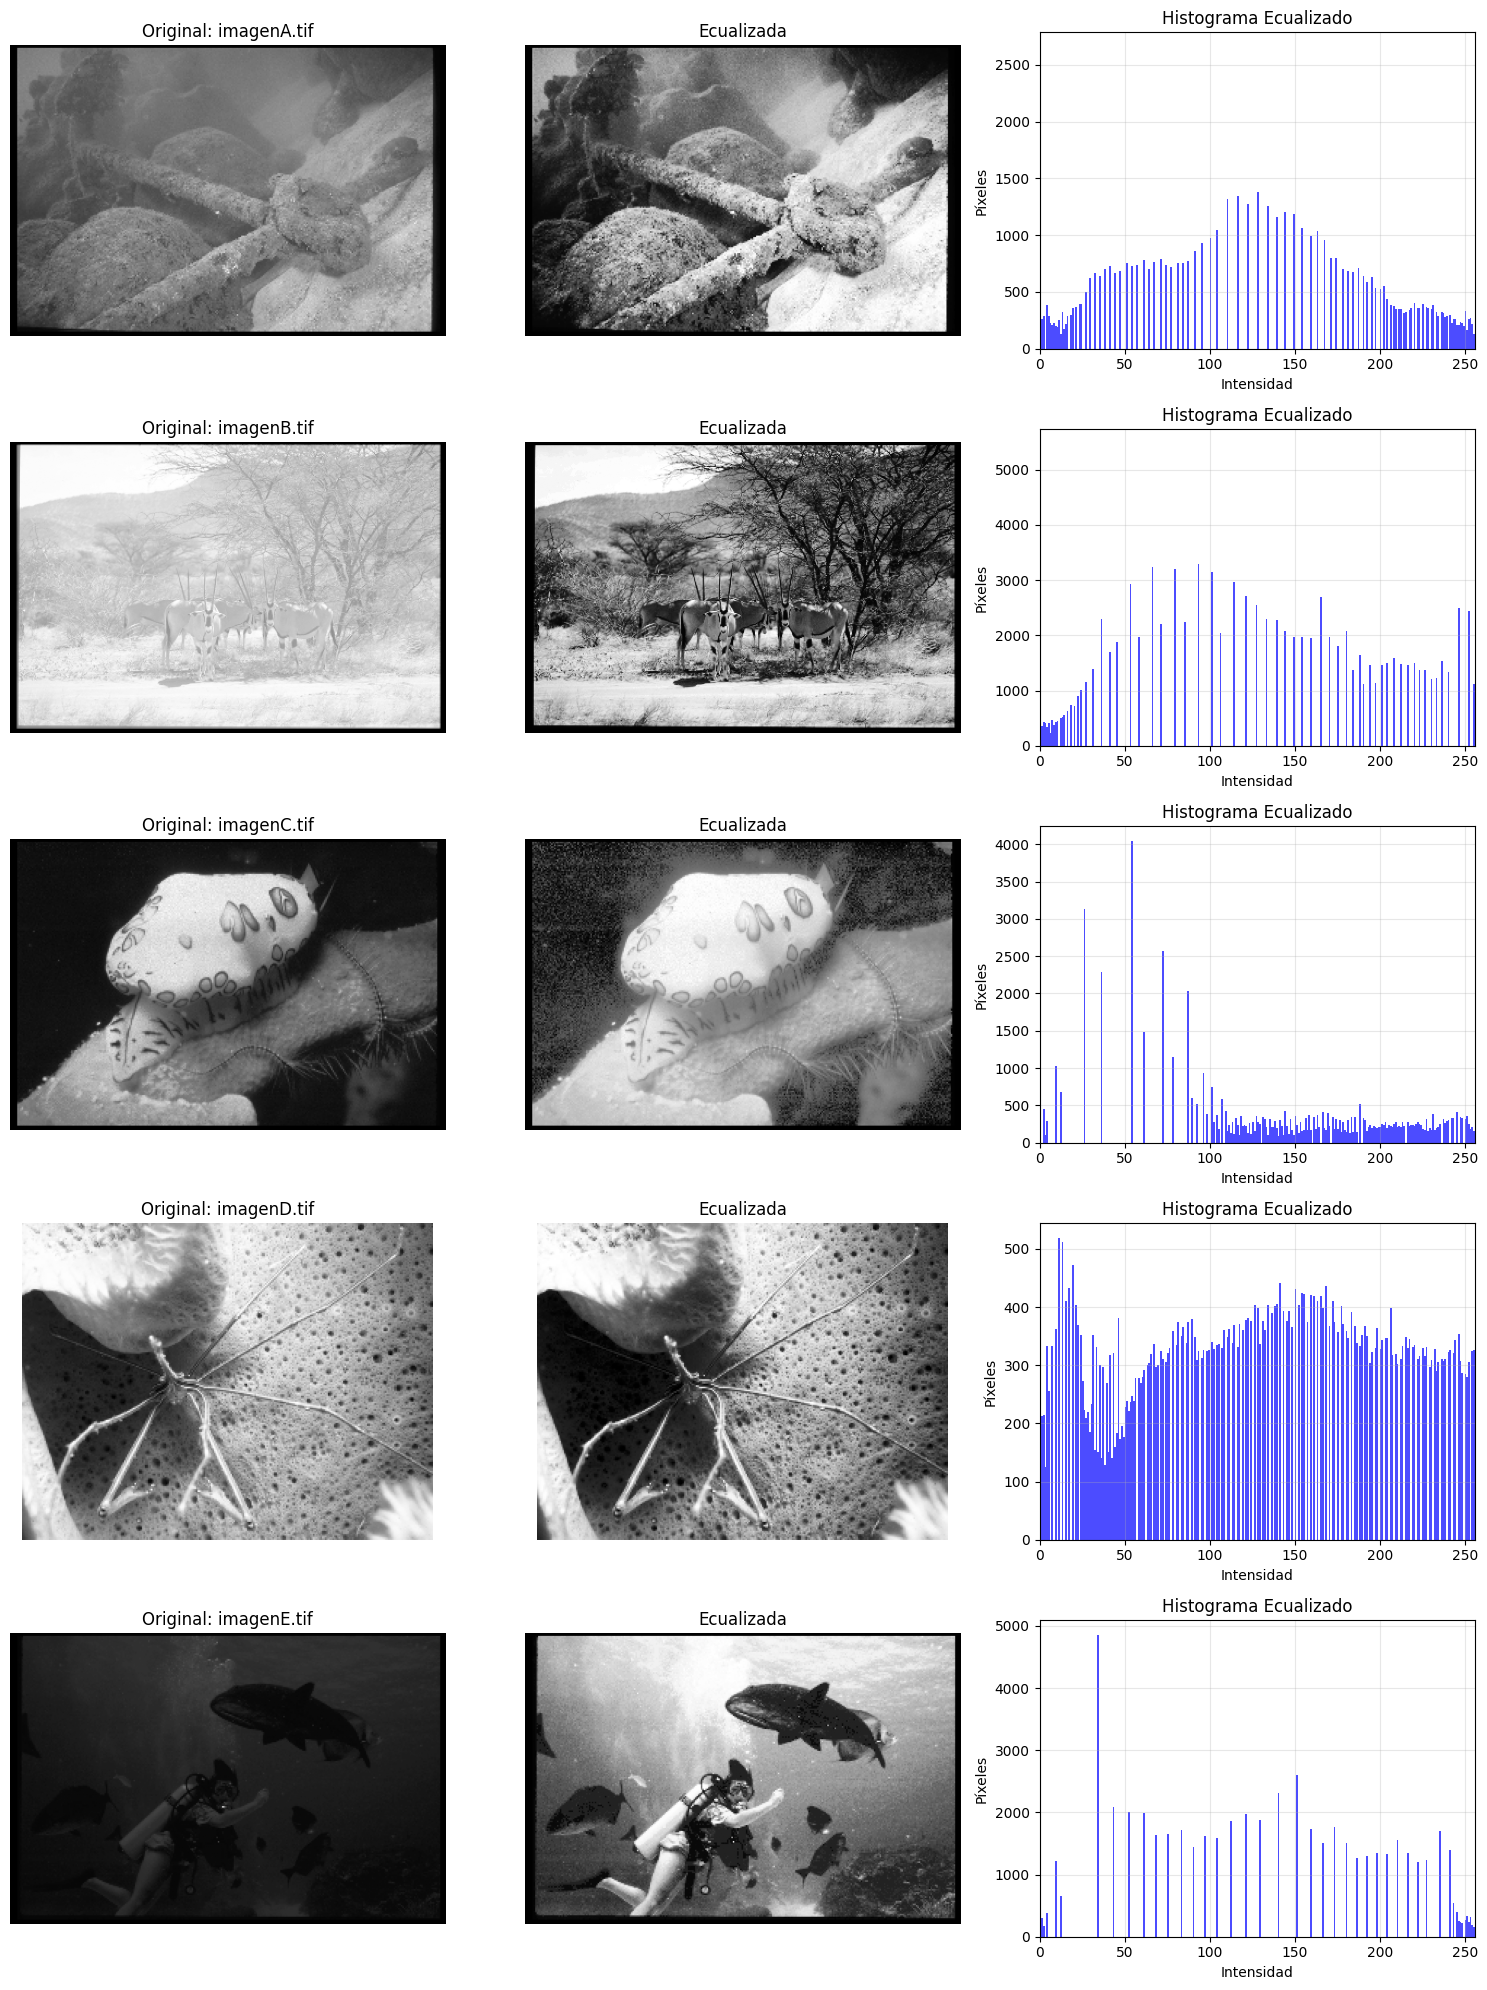

In [14]:

rutas = [
    "../Imagenes_cursado/imagenA.tif",
    "../Imagenes_cursado/imagenB.tif",
    "../Imagenes_cursado/imagenC.tif",
    "../Imagenes_cursado/imagenD.tif",
    "../Imagenes_cursado/imagenE.tif"
]


plt.figure(figsize=(15, 4 * len(rutas)))

for i, ruta in enumerate(rutas):
    img = cv2.imread(ruta, cv2.IMREAD_GRAYSCALE)
    
    if img is not None:
        img_eq = cv2.equalizeHist(img)


        plt.subplot(len(rutas), 3, 3 * i + 1)
        plt.imshow(img, cmap="gray")
        plt.title(f'Original: {ruta.split("/")[-1]}')
        plt.axis('off')

        plt.subplot(len(rutas), 3, 3 * i + 2)
        plt.imshow(img_eq, cmap="gray")
        plt.title('Ecualizada')
        plt.axis('off')


        plt.subplot(len(rutas), 3, 3 * i + 3)
        plt.hist(img_eq.ravel(), bins=256, range=[0, 256], color='blue', alpha=0.7)
        plt.title('Histograma Ecualizado')
        plt.xlabel('Intensidad')
        plt.ylabel('Píxeles')
        plt.xlim([0, 256])
        plt.grid(True, alpha=0.3)
    else:
        print(f"No se pudo cargar: {ruta}")

plt.tight_layout()
plt.show()

vemos que en algunos casos funcion, en otros casos no como por ejemplo aquellas donde habia una clara distincion entre fondo y objeto